# Trabajo Práctico N.º 1
## Geometría de Rotación, Dualidad de SO(3) y Composición

**Asignatura:** Robótica — IMT-342  
**Gestión:** II-2026  
**Integrantes:** Mario Alberto Nina Gallo — Roberth Williams Ruiz Condori  
**Entregable:** Notebook en la rama `feature/tp1-rotation`

Este notebook reúne el desarrollo teórico, la implementación numérica y las evidencias manuscritas correspondientes a los ejercicios de la Guía Práctica 1.

## 0. Configuración y funciones auxiliares

Se utiliza `NumPy` para implementar las matrices de rotación y realizar los cálculos numéricos.

La instrucción `np.set_printoptions(precision=6, suppress=True)` **solo modifica la forma en que NumPy muestra los arreglos**:

- `precision=6`: presenta los valores con una precisión visual de seis cifras decimales.
- `suppress=True`: evita mostrar residuos numéricos muy pequeños en notación científica dentro de los arreglos, por ejemplo valores del orden de $10^{-17}$, que visualmente pueden aparecer como `0.`.

Esta configuración **no modifica los valores usados en los cálculos**. Para la validación del error de ortogonalidad se imprime explícitamente el valor en notación científica.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)


In [2]:
def rot_x(deg):
    theta = np.deg2rad(deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta),  np.cos(theta)]
    ], dtype=float)


def rot_y(deg):
    theta = np.deg2rad(deg)
    return np.array([
        [ np.cos(theta), 0, np.sin(theta)],
        [0,              1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ], dtype=float)


def rot_z(deg):
    theta = np.deg2rad(deg)
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ], dtype=float)


## 1. Fundamento teórico: rotaciones en $SO(3)$

Una matriz de rotación tridimensional pertenece al grupo especial ortogonal $SO(3)$ cuando cumple:

$$
R^T R = I
$$

y

$$
\det(R)=1.
$$

Las matrices canónicas de rotación alrededor de los ejes $X$, $Y$ y $Z$ son:

$$
R_x(\theta)=
\begin{bmatrix}
1 & 0 & 0\\
0 & \cos\theta & -\sin\theta\\
0 & \sin\theta & \cos\theta
\end{bmatrix},
$$

$$
R_y(\theta)=
\begin{bmatrix}
\cos\theta & 0 & \sin\theta\\
0 & 1 & 0\\
-\sin\theta & 0 & \cos\theta
\end{bmatrix},
$$

$$
R_z(\theta)=
\begin{bmatrix}
\cos\theta & -\sin\theta & 0\\
\sin\theta & \cos\theta & 0\\
0 & 0 & 1
\end{bmatrix}.
$$

Estas matrices permiten representar rotaciones activas de vectores y cambios de coordenadas entre sistemas de referencia.

# 2. Ejercicio 1 — Dualidad activa vs. pasiva

Se considera:

$$
p=
\begin{bmatrix}
1\\
2\\
0
\end{bmatrix},
\qquad
R_z(90^\circ)=
\begin{bmatrix}
0 & -1 & 0\\
1 & 0 & 0\\
0 & 0 & 1
\end{bmatrix}.
$$

## 2.1 Caso A — Transformación activa

En una transformación activa, el sistema de referencia $\{A\}$ permanece fijo y el vector físico rota.

$$
p'=R_z(90^\circ)p
$$

$$
p'=
\begin{bmatrix}
0 & -1 & 0\\
1 & 0 & 0\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1\\
2\\
0
\end{bmatrix}
=
\begin{bmatrix}
-2\\
1\\
0
\end{bmatrix}.
$$

Por tanto, el vector original $p=(1,2,0)^T$ se transforma en $p'=(-2,1,0)^T$, ambos expresados en el mismo marco fijo $\{A\}$.

In [3]:
p = np.array([1, 2, 0], dtype=float)
Rz_90 = rot_z(90)
p_prima = Rz_90 @ p

print("Matriz Rz(90°):")
print(Rz_90)
print("\nVector original p:")
print(p)
print("\nVector transformado p':")
print(p_prima)


Matriz Rz(90°):
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

Vector original p:
[1. 2. 0.]

Vector transformado p':
[-2.  1.  0.]


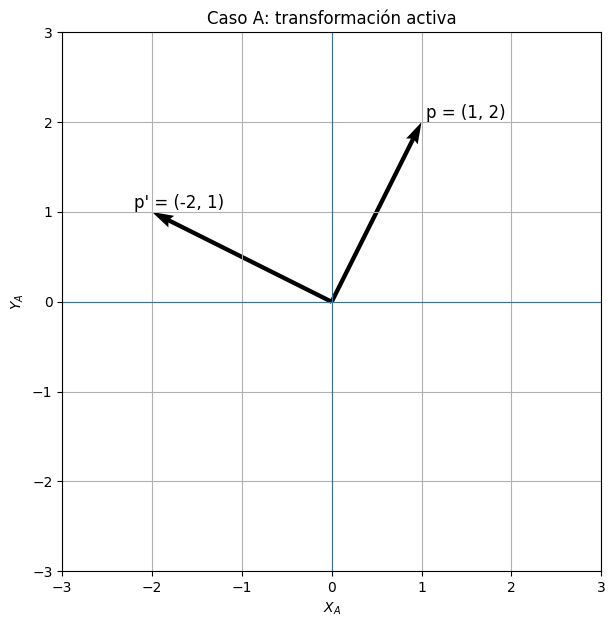

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.quiver(0, 0, p[0], p[1], angles='xy', scale_units='xy', scale=1, width=0.008)
ax.quiver(0, 0, p_prima[0], p_prima[1], angles='xy', scale_units='xy', scale=1, width=0.008)

ax.text(1.05, 2.05, 'p = (1, 2)', fontsize=12)
ax.text(-2.2, 1.05, "p' = (-2, 1)", fontsize=12)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xlabel('$X_A$')
ax.set_ylabel('$Y_A$')
ax.set_title('Caso A: transformación activa')
ax.grid(True)
ax.set_aspect('equal')

plt.show()


## 2.2 Caso B — Transformación pasiva

En una transformación pasiva, el punto físico permanece sin cambiar. Lo que cambia es el sistema de referencia empleado para expresar sus coordenadas.

Se tiene:

$$
p_B=
\begin{bmatrix}
1\\
2\\
0
\end{bmatrix}
$$

y, debido a que el marco $\{B\}$ está rotado $90^\circ$ respecto a $\{A\}$ alrededor de $Z_A$,

$$
{}^A R_B=R_z(90^\circ).
$$

Por tanto,

$$
p_A={}^A R_Bp_B
=
\begin{bmatrix}
0 & -1 & 0\\
1 & 0 & 0\\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1\\
2\\
0
\end{bmatrix}
=
\begin{bmatrix}
-2\\
1\\
0
\end{bmatrix}.
$$

El punto físico es el mismo; únicamente cambia su representación coordenada.

In [5]:
p_B_e1 = np.array([1, 2, 0], dtype=float)
ARB_e1 = rot_z(90)
p_A_e1 = ARB_e1 @ p_B_e1

print("Matriz ^A R_B:")
print(ARB_e1)
print("\nVector p_B:")
print(p_B_e1)
print("\nVector p_A:")
print(p_A_e1)


Matriz ^A R_B:
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

Vector p_B:
[1. 2. 0.]

Vector p_A:
[-2.  1.  0.]


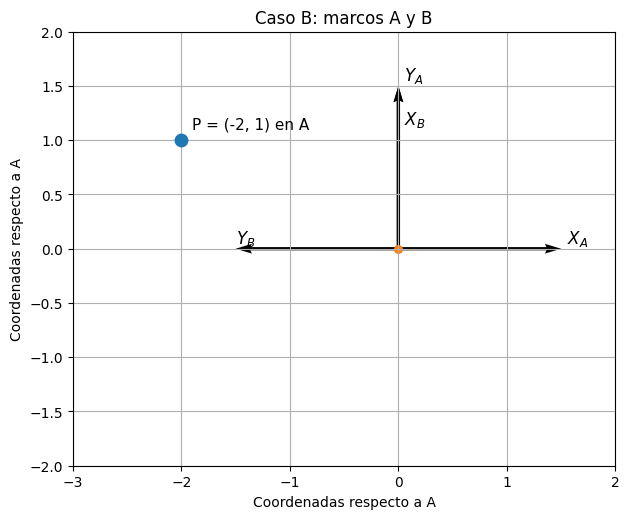

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
L = 1.5

# Marco A
ax.quiver(0, 0, L, 0, angles='xy', scale_units='xy', scale=1, width=0.006)
ax.quiver(0, 0, 0, L, angles='xy', scale_units='xy', scale=1, width=0.006)

# Marco B: X_B coincide con +Y_A y Y_B con -X_A
ax.quiver(0, 0, 0, L, angles='xy', scale_units='xy', scale=1, width=0.006)
ax.quiver(0, 0, -L, 0, angles='xy', scale_units='xy', scale=1, width=0.006)

ax.scatter(p_A_e1[0], p_A_e1[1], s=80, zorder=5)
ax.text(p_A_e1[0] + 0.1, p_A_e1[1] + 0.1, 'P = (-2, 1) en A', fontsize=11)

ax.text(1.55, 0.05, '$X_A$', fontsize=12)
ax.text(0.05, 1.55, '$Y_A$', fontsize=12)
ax.text(0.05, 1.15, '$X_B$', fontsize=12)
ax.text(-1.5, 0.05, '$Y_B$', fontsize=12)

ax.scatter(0, 0, s=30)
ax.set_xlim(-3, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel('Coordenadas respecto a A')
ax.set_ylabel('Coordenadas respecto a A')
ax.set_title('Caso B: marcos A y B')
ax.grid(True)
ax.set_aspect('equal')

plt.show()


### Interpretación geométrica del Caso B

El eje $X_B$ coincide con la dirección positiva de $Y_A$, mientras que el eje $Y_B$ coincide con la dirección negativa de $X_A$.

Por ello:

- una coordenada positiva sobre $X_B$ contribuye en la dirección $+Y_A$;
- una coordenada positiva sobre $Y_B$ contribuye en la dirección $-X_A$.

En consecuencia, las coordenadas $(1,2)$ en el marco $\{B\}$ representan el mismo punto físico que las coordenadas $(-2,1)$ en el marco $\{A\}$.

## 2.3 Evidencia manuscrita — Ejercicio 1

**Ubicación esperada de los archivos:**

`2-2026/IMT342/equipo/practicas/tp1-rotation/evidencias/`

Las cuatro hojas de Mario deben estar guardadas con estos nombres:

- `ejercicio1_hoja_1.jpg`
- `ejercicio1_hoja_2.jpg`
- `ejercicio1_hoja_3.jpg`
- `ejercicio1_hoja_4.jpg`

A continuación se muestran automáticamente cuando los archivos están presentes en la carpeta `evidencias/`.

### Hoja 1
![Ejercicio 1 - hoja 1](evidencias/ejercicio1_hoja_1.jpg)

### Hoja 2
![Ejercicio 1 - hoja 2](evidencias/ejercicio1_hoja_2.jpg)

### Hoja 3
![Ejercicio 1 - hoja 3](evidencias/ejercicio1_hoja_3.jpg)

### Hoja 4
![Ejercicio 1 - hoja 4](evidencias/ejercicio1_hoja_4.jpg)

# 3. Ejercicio 2 — Composición de rotaciones: ejes fijos y móviles

El marco móvil $\{B\}$, inicialmente alineado con el marco fijo $\{A\}$, realiza:

1. $45^\circ$ alrededor de $X_A$ fijo.
2. $90^\circ$ alrededor de $Z_B$ móvil.
3. $-45^\circ$ alrededor de $Y_A$ fijo.

Las rotaciones alrededor de **ejes fijos** se incorporan mediante pre-multiplicación, mientras que una rotación alrededor de un **eje móvil** se incorpora mediante post-multiplicación.

## 3.1 Primera rotación: $45^\circ$ alrededor de $X_A$

Como $X_A$ es un eje fijo:

$$
R_1=R_x(45^\circ)
=
\begin{bmatrix}
1 & 0 & 0\\
0 & \frac{\sqrt2}{2} & -\frac{\sqrt2}{2}\\
0 & \frac{\sqrt2}{2} & \frac{\sqrt2}{2}
\end{bmatrix}.
$$

## 3.2 Segunda rotación: $90^\circ$ alrededor de $Z_B$

Como $Z_B$ pertenece al marco móvil, la nueva rotación se **post-multiplica**:

$$
R_2=R_1R_z(90^\circ)
=R_x(45^\circ)R_z(90^\circ).
$$

Con

$$
R_z(90^\circ)=
\begin{bmatrix}
0 & -1 & 0\\
1 & 0 & 0\\
0 & 0 & 1
\end{bmatrix}.
$$

## 3.3 Tercera rotación: $-45^\circ$ alrededor de $Y_A$

Como $Y_A$ es un eje fijo, la tercera rotación se **pre-multiplica**:

$$
{}^A R_B
=
R_y(-45^\circ)R_2.
$$

Así,

$$
\boxed{
{}^A R_B
=
R_y(-45^\circ)R_x(45^\circ)R_z(90^\circ)
}
$$

con

$$
R_y(-45^\circ)=
\begin{bmatrix}
\frac{\sqrt2}{2} & 0 & -\frac{\sqrt2}{2}\\
0 & 1 & 0\\
\frac{\sqrt2}{2} & 0 & \frac{\sqrt2}{2}
\end{bmatrix}.
$$

## 3.4 Matriz final analítica

Primero,

$$
R_x(45^\circ)R_z(90^\circ)
=
\begin{bmatrix}
0 & -1 & 0\\
\frac{\sqrt2}{2} & 0 & -\frac{\sqrt2}{2}\\
\frac{\sqrt2}{2} & 0 & \frac{\sqrt2}{2}
\end{bmatrix}.
$$

Luego,

$$
{}^A R_B
=
R_y(-45^\circ)
\left[R_x(45^\circ)R_z(90^\circ)\right],
$$

por lo que

$$
\boxed{
{}^A R_B=
\begin{bmatrix}
-\frac12 & -\frac{\sqrt2}{2} & -\frac12\\
\frac{\sqrt2}{2} & 0 & -\frac{\sqrt2}{2}\\
\frac12 & -\frac{\sqrt2}{2} & \frac12
\end{bmatrix}
}
$$

y aproximadamente

$$
{}^A R_B\approx
\begin{bmatrix}
-0.5 & -0.7071 & -0.5\\
0.7071 & 0 & -0.7071\\
0.5 & -0.7071 & 0.5
\end{bmatrix}.
$$

## 3.5 Evidencia manuscrita — Ejercicio 2

**Ubicación esperada de los archivos:**

`2-2026/IMT342/equipo/practicas/tp1-rotation/evidencias/`

Las hojas del Ejercicio 2 de Roberth deben guardarse con estos nombres:

- `ejercicio2_hoja_1.jpg`
- `ejercicio2_hoja_2.jpg`
- `ejercicio2_hoja_3.jpg`

### Hoja 1
![Ejercicio 2 - hoja 1](evidencias/ejercicio2_hoja_1.jpg)

### Hoja 2
![Ejercicio 2 - hoja 2](evidencias/ejercicio2_hoja_2.jpg)

### Hoja 3
![Ejercicio 2 - hoja 3](evidencias/ejercicio2_hoja_3.jpg)


# 4. Ejercicio 3 — Implementación y validación en Python

Las funciones `rot_x(deg)`, `rot_y(deg)` y `rot_z(deg)` fueron definidas al inicio del notebook para poder reutilizarlas en todos los cálculos.

## 4.1 Cálculo numérico de la matriz final

In [7]:
R_final = rot_y(-45) @ rot_x(45) @ rot_z(90)

print("Matriz de rotación final ^A R_B:")
print(R_final)


Matriz de rotación final ^A R_B:
[[-0.5      -0.707107 -0.5     ]
 [ 0.707107  0.       -0.707107]
 [ 0.5      -0.707107  0.5     ]]


La matriz obtenida numéricamente coincide con la matriz calculada analíticamente en el Ejercicio 2.

## 4.2 Validación de ortogonalidad

In [8]:
I = np.eye(3)
RT_R = R_final.T @ R_final
error_frobenius = np.linalg.norm(RT_R - I, ord='fro')

print("R^T R:")
print(RT_R)
print("\n||R^T R - I||_F =", f"{error_frobenius:.3e}")
print("¿Cumple ||R^T R - I||_F < 10^-15?", error_frobenius < 1e-15)


R^T R:
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

||R^T R - I||_F = 1.570e-16
¿Cumple ||R^T R - I||_F < 10^-15? True


Como

$$
\left\|R^TR-I\right\|_F \approx 1.57\times10^{-16}<10^{-15},
$$

se satisface la condición de ortogonalidad solicitada.

## 4.3 Transformación del vector

In [9]:
p_B = np.array([2, -1, 4], dtype=float)
p_A = R_final @ p_B

print("Vector p_B:")
print(p_B)
print("\nVector p_A:")
print(p_A)


Vector p_B:
[ 2. -1.  4.]

Vector p_A:
[-2.292893 -1.414214  3.707107]


## 4.4 Conservación de la norma

In [10]:
norma_p_B = np.linalg.norm(p_B)
norma_p_A = np.linalg.norm(p_A)
diferencia_normas = norma_p_A - norma_p_B

print("||p_B|| =", norma_p_B)
print("||p_A|| =", norma_p_A)
print("||p_A|| - ||p_B|| =", f"{diferencia_normas:.3e}")
print("¿Se conserva la norma?", np.isclose(norma_p_A, norma_p_B))


||p_B|| = 4.58257569495584
||p_A|| = 4.58257569495584
||p_A|| - ||p_B|| = 0.000e+00
¿Se conserva la norma? True


La transformación conserva la norma del vector:

$$
\|p_B\|=\|p_A\|\approx 4.58257569,
$$

y numéricamente

$$
\|p_A\|-\|p_B\|=0
$$

dentro de la precisión de punto flotante.

# 5. Conclusiones

En el Ejercicio 1 se comprobó la dualidad entre una transformación activa y una transformación pasiva. En el caso activo, el vector rota mientras el sistema de referencia permanece fijo. En el caso pasivo, el punto físico permanece invariable y cambian únicamente las coordenadas utilizadas para describirlo.

En el Ejercicio 2 se obtuvo la composición

$$
{}^A R_B=
R_y(-45^\circ)R_x(45^\circ)R_z(90^\circ),
$$

donde las rotaciones alrededor de ejes fijos se incorporaron mediante pre-multiplicación y la rotación alrededor del eje móvil mediante post-multiplicación.

En el Ejercicio 3, la matriz obtenida analíticamente fue reproducida con `NumPy`. La validación numérica produjo un error de ortogonalidad del orden de $10^{-16}$, inferior al límite $10^{-15}$ establecido en la guía. Además, la transformación del vector $p_B=[2,-1,4]^T$ conservó su norma.

Por tanto, los resultados analíticos y numéricos son consistentes con las propiedades de las matrices de rotación de $SO(3)$.